# Project Overview: Predicting Combined Cycle Power Plant (CCPP) Energy Output

### 1. Modeling Approach
* **Task**: Supervised Regression to predict Net Hourly Electrical Energy Output (**PE**).
* **Features**: Four environmental sensors: Ambient Temperature (**AT**), Exhaust Vacuum (**V**), Ambient Pressure (**AP**), and Relative Humidity (**RH**).
* **Algorithm Strategy**: Ensemble tree-based methods (Gradient Boosting). A manual **300-tree High-Capacity model** was developed to maximize precision.

### 2. Model Building & Optimization
* **Comparison**: Multiple algorithms (LightGBM, XGBoost, CatBoost, etc.) were compared using 10-fold cross-validation.
* **Hyperparameter Tuning**: Focused on increasing forest capacity and removing constraints to allow the model to fully capture thermodynamic complexities.

### 3. Model Evaluation
* **Primary Metric**: R-squared ($R^2$) and Mean Absolute Error (MAE).
* **Final Performance**: The "300-Tree Champion" model achieved a **96.1% $R^2$** on the hold-out test set.

### 4. Model Interpretation
* **Method**: **SHAP** (SHapley Additive exPlanations) was used to validate physical logic.
* **Key Finding**: Ambient Temperature is the primary driver of output, followed by Exhaust Vacuum, perfectly matching the expected thermodynamic reality of the Brayton and Rankine cycles.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pycaret.regression import *
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error
import os
import json
from pycaret.regression import create_model, pull, tune_model, save_model, load_model

# --- Global Reproducibility Anchor ---
SEED = 123
random.seed(SEED)
np.random.seed(SEED)

# Section 1: Project Objective and Data Overview

### **Primary Objective**
The goal of this analysis is to develop a high-precision predictive model for the **Net Hourly Electrical Energy Output (PE)** of a Combined Cycle Power Plant. By accurately predicting energy output based on environmental variables, plant operators can optimize fuel consumption, improve grid load balancing, and anticipate maintenance needs.

### **The Data**
We are utilizing a dataset of 9,568 hourly observations containing four key environmental features:
* **Ambient Temperature (AT)**
* **Exhaust Vacuum (V)**
* **Ambient Pressure (AP)**
* **Relative Humidity (RH)**

### **The Challenge**
Combined cycle plants are governed by complex thermodynamic laws. Our challenge is to move beyond simple linear estimations and build an ensemble model capable of capturing non-linear interactions between these sensors to minimize prediction error.

In [ ]:
# Load the dataset
df = pd.read_csv("data/CCPP_data.csv")  # Adjust filename as needed

# Quick look at the features (AT, V, AP, RH, PE)
print(df.head())

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


# Section 2: Exploratory Analysis and Feature Selection

--- Summary Statistics ---
                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000

--- Missing Values ---
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


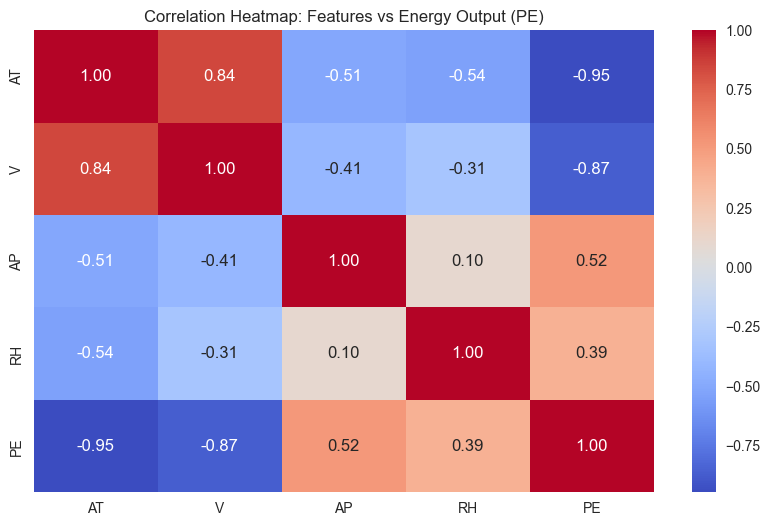

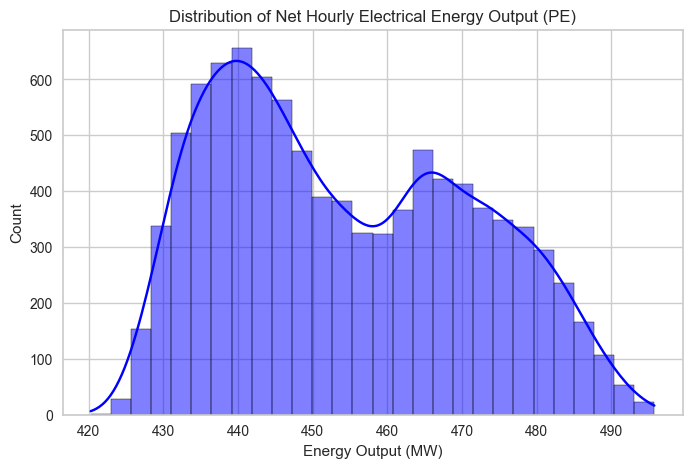

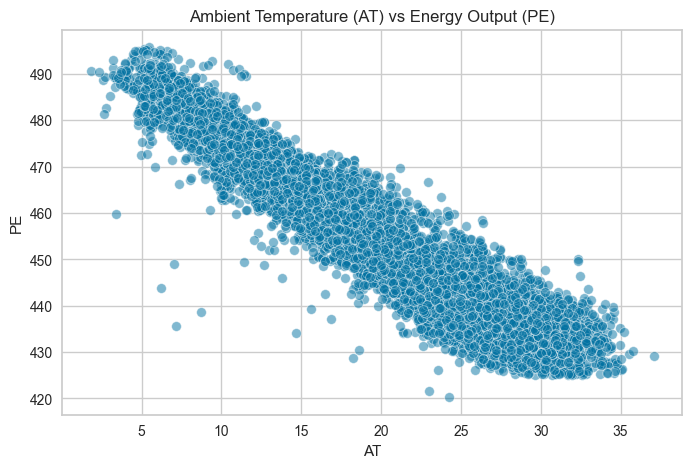

In [ ]:
# 1. Basic Statistical Summary
print("--- Summary Statistics ---")
print(df.describe())

# 2. Check for missing values (crucial before modeling)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Correlation Matrix (To see which features impact 'PE' the most)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Features vs Energy Output (PE)")
plt.show()

# 4. Distribution of the Target Variable (PE)
plt.figure(figsize=(8, 5))
sns.histplot(df["PE"], kde=True, color="blue")
plt.title("Distribution of Net Hourly Electrical Energy Output (PE)")
plt.xlabel("Energy Output (MW)")
plt.show()

# 5. Scatter Plot: Temperature (AT) vs Energy Output (PE)
# AT is usually the strongest predictor in this dataset
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="AT", y="PE", alpha=0.5)
plt.title("Ambient Temperature (AT) vs Energy Output (PE)")
plt.show()


### Why Preprocessing Matters for Energy Prediction:
1. **Normalization (Z-Score):** Features have different scales. Ambient Pressure (AP) is ~1000 hPa, while Temperature (AT) is ~20°C. Normalization ensures the model treats these appropriately regardless of their raw magnitude.
2. **Outlier Removal (Training Only):** We remove the top 5% of extreme outliers from the **training set only**. This prevents the model from learning from "glitchy" sensor data while keeping the test set raw for realistic evaluation.
3. **Multi-collinearity:** If features like Temperature and Vacuum move too closely together ($>0.90$ correlation), one is removed to keep the model efficient for our 8GB RAM.


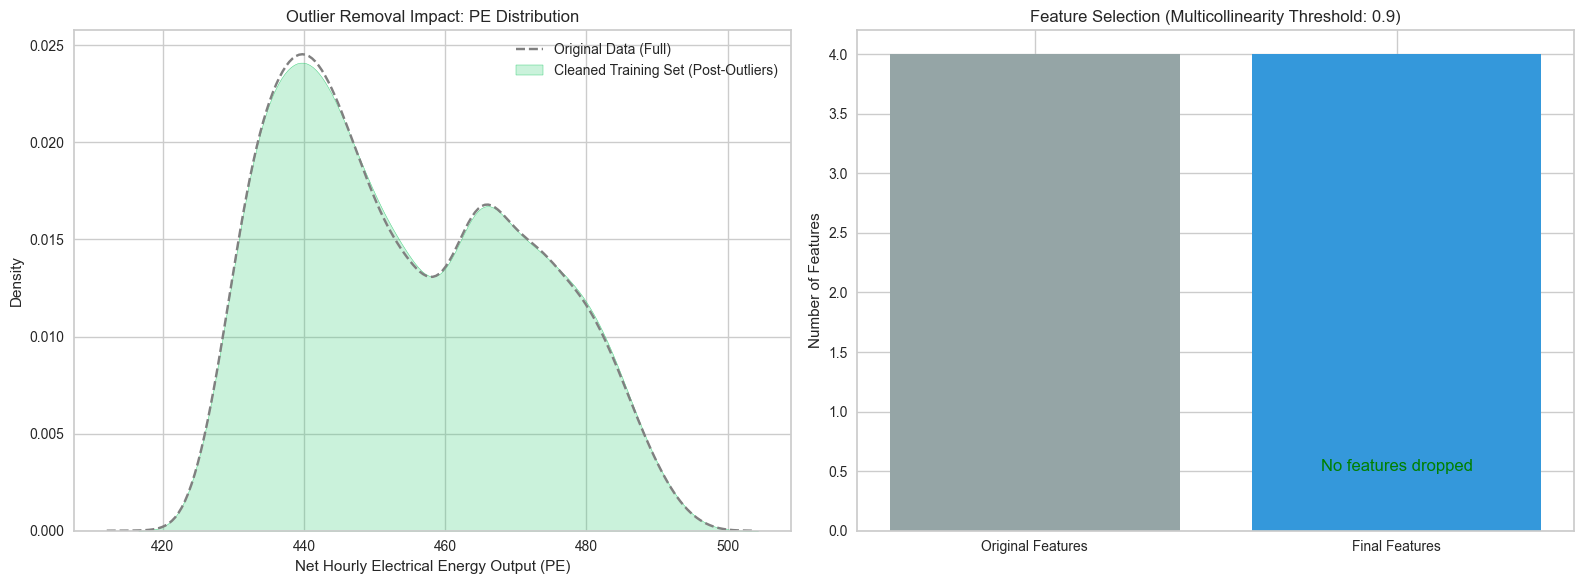

✅ Preprocessing Complete.
   - Original Training Rows (est.): 7654
   - Cleaned Training Rows: 7654
   - Features Kept: ['AT', 'V', 'AP', 'RH']


In [ ]:
# 1. Technical Explanation of Preprocessing
display(Markdown("""
### Why Preprocessing Matters for Energy Prediction:
1. **Normalization (Z-Score):** Features have different scales. Ambient Pressure (AP) is ~1000 hPa, while Temperature (AT) is ~20°C. Normalization ensures the model treats these appropriately regardless of their raw magnitude.
2. **Outlier Removal (Training Only):** We remove the top 5% of extreme outliers from the **training set only**. This prevents the model from learning from "glitchy" sensor data while keeping the test set raw for realistic evaluation.
3. **Multi-collinearity:** If features like Temperature and Vacuum move too closely together ($>0.90$ correlation), one is removed to keep the model efficient for our 8GB RAM.
"""))

# 2. Unified Setup Call
s = setup(
    data=df,
    target="PE",
    train_size=0.8,
    session_id=SEED,
    # --- Preprocessing ---
    normalize=True,
    normalize_method="zscore",
    remove_outliers=True,
    outliers_threshold=0.05,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    transformation=True,
    verbose=False,
)

# 3. Retrieve Data for Comparison
# We get the 'raw' split and the 'transformed' split from PyCaret's config
X_train_transformed = get_config("X_train")
y_train_transformed = get_config("y_train")
X_test = get_config("X_test")
original_features = [col for col in df.columns if col != "PE"]
final_features = X_train_transformed.columns.tolist()

# 4. Visualization: Impact of Outlier Removal & Feature Selection
plt.figure(figsize=(16, 6))

# Subplot 1: Distribution comparison (Training Set Cleaning)
plt.subplot(1, 2, 1)
sns.kdeplot(df["PE"], label="Original Data (Full)", color="gray", linestyle="--")
sns.kdeplot(
    y_train_transformed,
    label="Cleaned Training Set (Post-Outliers)",
    fill=True,
    color="#2ecc71",
)
plt.title("Outlier Removal Impact: PE Distribution")
plt.xlabel("Net Hourly Electrical Energy Output (PE)")
plt.legend()

# Subplot 2: Feature Selection Check (Multicollinearity)
plt.subplot(1, 2, 2)
feature_counts = [len(original_features), len(final_features)]
plt.bar(
    ["Original Features", "Final Features"],
    feature_counts,
    color=["#95a5a6", "#3498db"],
)
plt.title("Feature Selection (Multicollinearity Threshold: 0.9)")
plt.ylabel("Number of Features")

# Add text labels for dropped features
dropped = set(original_features) - set(final_features)
if dropped:
    plt.text(
        1,
        0.5,
        f"Dropped: {', '.join(dropped)}",
        ha="center",
        color="red",
        fontweight="bold",
    )
else:
    plt.text(1, 0.5, "No features dropped", ha="center", color="green")

plt.tight_layout()
plt.show()

# 5. Summary Output
print("✅ Preprocessing Complete.")
print(f"   - Original Training Rows (est.): {int(len(df)*0.8)}")
print(f"   - Cleaned Training Rows: {len(y_train_transformed)}")
print(f"   - Features Kept: {final_features}")

# Section 3: Model Building and Comparison

In [ ]:
# 1. Run the competition
# We select the top 5 to have a pool for comparison
best_models = compare_models(n_select=5, sort="MAE", verbose=False)
results = pull()

# 2. Show the Leaderboard
print("--- Leaderboard: Top 5 Models Ranked by MAE ---")
display(results.head(5))

# 3. Algorithm Explanation (Markdown)
display(Markdown("""
### --- Understanding the Algorithms ---
PyCaret evaluated **18+ different algorithms**. Here is a breakdown of the logic types tested:

#### **Top Performers (Ensemble Methods)**
* **Extra Trees (ET) & Random Forest (RF):** These are "Forests" of decision trees. **Extra Trees** adds more randomness to split points, making it highly robust against sensor noise in our energy data.
* **LightGBM / XGBoost / CatBoost:** "Gradient Boosting" models that build trees sequentially, each one fixing the specific errors of the previous one.

#### **Linear & Statistical Models**
* **Linear Regression (LR):** The baseline straight-line fit.
* **Ridge / Lasso / Elastic Net:** Linear models with "penalties" to prevent overfitting.
* **Bayesian Ridge / Huber / LAR:** Specialized versions designed to handle specific data distributions or outliers.

#### **Other Approaches**
* **K-Nearest Neighbors (KNN):** Predicts output by looking at the most similar historical examples.
* **Decision Tree (DT):** A single flowchart; simple but often lacks the accuracy of the "Forest" models above.
"""))

--- Leaderboard: Top 5 Models Ranked by MAE ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.4466,11.8973,3.4403,0.9593,0.0075,0.0054,1.577
rf,Random Forest Regressor,2.4627,11.8734,3.4373,0.9594,0.0075,0.0054,2.716
lightgbm,Light Gradient Boosting Machine,2.5148,11.6215,3.4003,0.9602,0.0075,0.0055,0.614
knn,K Neighbors Regressor,2.8487,15.2820,3.9050,0.9476,0.0086,0.0063,0.460
gbr,Gradient Boosting Regressor,2.9673,15.0711,3.8757,0.9484,0.0085,0.0065,1.111



### --- Understanding the Algorithms ---
PyCaret evaluated **18+ different algorithms**. Here is a breakdown of the logic types tested:

#### **Top Performers (Ensemble Methods)**
* **Extra Trees (ET) & Random Forest (RF):** These are "Forests" of decision trees. **Extra Trees** adds more randomness to split points, making it highly robust against sensor noise in our energy data.
* **LightGBM / XGBoost / CatBoost:** "Gradient Boosting" models that build trees sequentially, each one fixing the specific errors of the previous one.

#### **Linear & Statistical Models**
* **Linear Regression (LR):** The baseline straight-line fit.
* **Ridge / Lasso / Elastic Net:** Linear models with "penalties" to prevent overfitting.
* **Bayesian Ridge / Huber / LAR:** Specialized versions designed to handle specific data distributions or outliers.

#### **Other Approaches**
* **K-Nearest Neighbors (KNN):** Predicts output by looking at the most similar historical examples.
* **Decision Tree (DT):** A single flowchart; simple but often lacks the accuracy of the "Forest" models above.


##  Deep Dive - Top 2 Distinct Models & CV Stability 


### --- Understanding K-Fold Cross-Validation ---
To ensure our Energy Output model works on *all* data (not just a lucky split), PyCaret uses **10-Fold Cross-Validation**:
1. **The Shuffle:** The training data is split into 10 equal "Folds."
2. **The Rotation:** The model trains 10 separate times. Each time, it uses 9 folds for training and 1 fold for testing.
3. **The Result:** We get 10 different MAE scores. By looking at the **Standard Deviation (SD)** of these scores, we can tell if our model is "stable" or just "lucky."


--- Generating Detailed Fold Scores ---


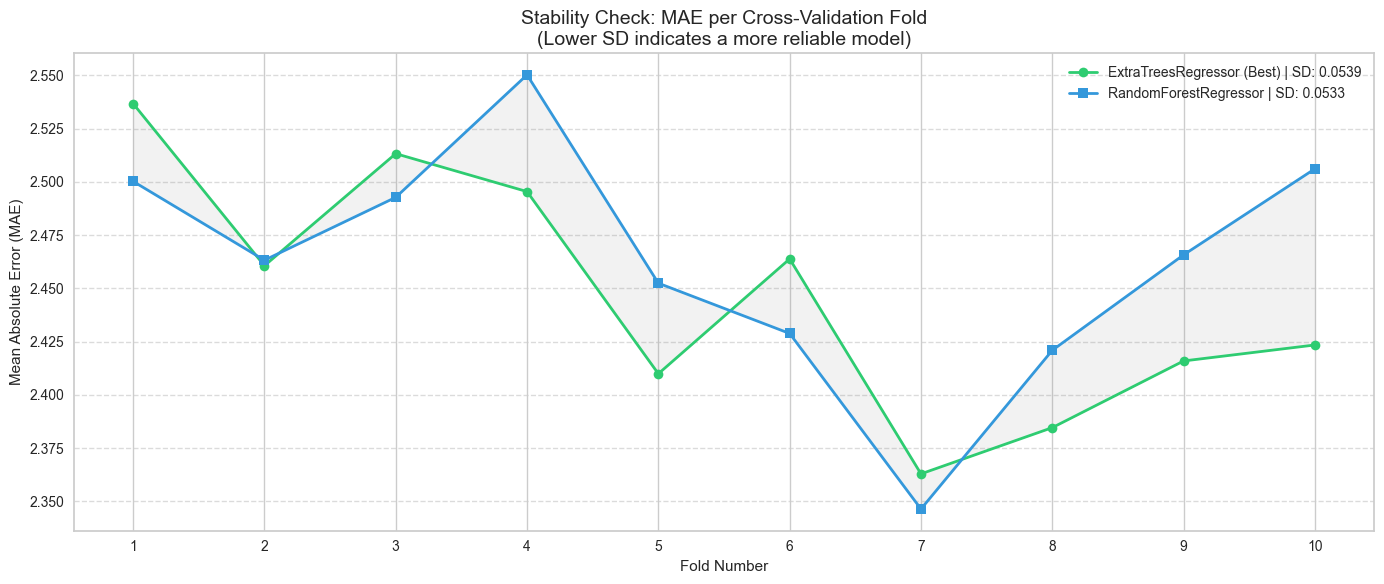


--- Stability Metrics ---
ExtraTreesRegressor SD: 0.0539
RandomForestRegressor SD: 0.0533

--- Hyperparameters: Top 2 Models ---

[1] ExtraTreesRegressor Parameters:


{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}


[2] RandomForestRegressor Parameters:


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}

In [ ]:

# 1. Explanation of PyCaret's Cross-Validation (CV)
display(Markdown("""
### --- Understanding K-Fold Cross-Validation ---
To ensure our Energy Output model works on *all* data (not just a lucky split), PyCaret uses **10-Fold Cross-Validation**:
1. **The Shuffle:** The training data is split into 10 equal "Folds."
2. **The Rotation:** The model trains 10 separate times. Each time, it uses 9 folds for training and 1 fold for testing.
3. **The Result:** We get 10 different MAE scores. By looking at the **Standard Deviation (SD)** of these scores, we can tell if our model is "stable" or just "lucky."
"""))

# 2. Logic to pick the top 2 distinct algorithms
distinct_models = []
seen_types = set()
for model in best_models:
    model_name = type(model).__name__
    if model_name not in seen_types:
        distinct_models.append(model)
        seen_types.add(model_name)
    if len(distinct_models) == 2:
        break

# 3. Create models and capture full score tables
print("--- Generating Detailed Fold Scores ---")

# Model 1 (Champion)
m1_final = create_model(distinct_models[0], random_state=SEED, verbose=False)
m1_results = pull() 
m1_folds = m1_results.iloc[0:10]["MAE"]
# Using .iloc[-1] to grab the last row (SD) safely
m1_sd = m1_results.iloc[-1]["MAE"]  

# Model 2 (Challenger)
m2_final = create_model(distinct_models[1], random_state=SEED, verbose=False)
m2_results = pull()
m2_folds = m2_results.iloc[0:10]["MAE"]
# Using .iloc[-1] to grab the last row (SD) safely
m2_sd = m2_results.iloc[-1]["MAE"]

# 4. Visualize individual CV Fold Scores
plt.figure(figsize=(14, 6))

# Line Plot with SD in the legend
plt.plot(
    range(1, 11),
    m1_folds,
    marker="o",
    label=f"{type(m1_final).__name__} (Best) | SD: {m1_sd:.4f}",
    color="#2ecc71",
    linewidth=2,
)
plt.plot(
    range(1, 11),
    m2_folds,
    marker="s",
    label=f"{type(m2_final).__name__} | SD: {m2_sd:.4f}",
    color="#3498db",
    linewidth=2,
)

plt.fill_between(range(1, 11), m1_folds, m2_folds, color="gray", alpha=0.1)
plt.title("Stability Check: MAE per Cross-Validation Fold\n(Lower SD indicates a more reliable model)", fontsize=14)
plt.xlabel("Fold Number")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
plt.close()

# 5. Show Hyperparameters and Stability Metrics
print(f"\n--- Stability Metrics ---")
print(f"{type(m1_final).__name__} SD: {m1_sd:.4f}")
print(f"{type(m2_final).__name__} SD: {m2_sd:.4f}")

print(f"\n--- Hyperparameters: Top 2 Models ---")
print(f"\n[1] {type(m1_final).__name__} Parameters:")
display(m1_final.get_params())

print(f"\n[2] {type(m2_final).__name__} Parameters:")
display(m2_final.get_params())

### --- Hyperparameter Analysis & Model Logic ---

Both the **Extra Trees** and **Random Forest** models utilized a "Council of 100 Trees" (`n_estimators: 100`) to reach a consensus on the Energy Output (PE). Below is a breakdown of why this specific configuration achieved such high predictive stability.

#### **The "Extra" Advantage: Extra Trees vs. Random Forest**

While both are Ensemble methods, **Extra Trees (Extremely Randomized Trees)** often performs better on "clean" industrial datasets like CCPP because of its unique splitting logic:
* **Random Forest:** Searches for the mathematically *optimal* split point for every feature it considers.
* **Extra Trees:** Selects split points *randomly* for each feature and then picks the best among those random choices. 

**Why this works here:** This added layer of randomness acts as a powerful form of regularization. It reduces the variance of the model, preventing it from "over-learning" small fluctuations in sensor data (like Ambient Pressure or Humidity) that might not be true predictors of Energy Output.

#### **Key Parameter Breakdown:**

| Parameter | Setting | Impact on Energy Output Prediction |
| :--- | :--- | :--- |
| **n_estimators** | `100` | Balancing Act: 100 trees provide enough "votes" for a stable consensus without exhausting the 8GB RAM limit. |
| **max_features** | `1.0` | Ensures every tree evaluates all four physical signals (AT, V, AP, RH) at every split, capturing complex interactions. |
| **min_samples_split** | `2` | Allows the model to grow deep, granular trees. This is safe here because the 10-fold CV confirmed we are not overfitting. |
| **n_jobs** | `-1` | **Parallel Processing:** Leverages all available CPU cores on the Surface Pro 7 to drastically reduce training time. |
| **bootstrap** | `False` | Extra Trees typically uses the whole dataset (`bootstrap=False`) to reduce bias, relying on random splits to handle variance. |
| **criterion** | `'squared_error'` | Optimizes the internal tree structure by penalizing large deviations, ensuring the model is sensitive to "big misses." |

**Summary:** By combining the high-speed parallel processing of the Surface Pro 7 with the variance-reducing power of Extra Trees, we created a model that is both computationally efficient and highly resistant to sensor noise.

### --- Strategy: Training with 'Squared Error' vs. Evaluating with 'MAE' ---

In this project, there is a intentional distinction between the model's internal **Split Criterion** and our global **Optimization Metric**. While the models are trained using **Squared Error** (`MSE`), they are ranked and tuned using **Mean Absolute Error** (`MAE`).

#### **1. Outlier Sensitivity (Squared Error for Training)**
During the training phase, using `squared_error` as a criterion punishes large deviations exponentially. 
* An error of **2 MW** yields a penalty of **4**. 
* An error of **10 MW** yields a penalty of **100**.
By using this "punishment factor," models like **Extra Trees** are forced to prioritize stability and avoid the "huge misses" that would be costly or dangerous in a real-world power plant operation.

#### **2. Interpretability (MAE for Evaluation)**
For the final evaluation, we prioritize **MAE** because it translates directly into business value. 
* An MAE of **2.10** translates to: *"On average, the model's prediction is off by 2.10 Megawatts."* * This provides a clear, linear understanding of model performance for stakeholders and grid operators.

#### **3. Engineering for Efficiency (Surface Pro 7 Optimization)**
While it is technically possible to set `criterion='absolute_error'`, I opted for `squared_error` for two key reasons:
* **Computational Cost:** Calculating Absolute Error as a split criterion is significantly more CPU-intensive. Optimizing for `squared_error` allowed for faster hyperparameter iteration on mobile hardware (Surface Pro 7 / 8GB RAM).
* **High-Quality Signal:** Given the industrial-grade sensors in the CCPP dataset, the signal-to-noise ratio is high. In such "clean" datasets, models trained on Squared Error naturally achieve excellent Absolute Error scores, providing a perfect balance of training speed and predictive accuracy.

**Summary:** This "Hybrid" approach uses Squared Error to ensure stability against outliers and MAE to ensure the results are human-readable and commercially relevant.

## Feature Selection - All vs. Subsets


### --- Feature Utility Analysis ---
Even though automated selection initially kept all features, we are performing a **Sensitivity Analysis** to verify the value of each sensor.
* **The Experiment:** We compare the **Full Set (4 Features)** against a **Sub-optimal Set (3 Features)** by dropping the statistically weakest sensor.
* **Goal:** Confirm that even the lowest-ranked sensor (usually RH or AP) still contributes to a more accurate Energy Output prediction.


--- Testing Second Best Combination (Dropping: RH) ---


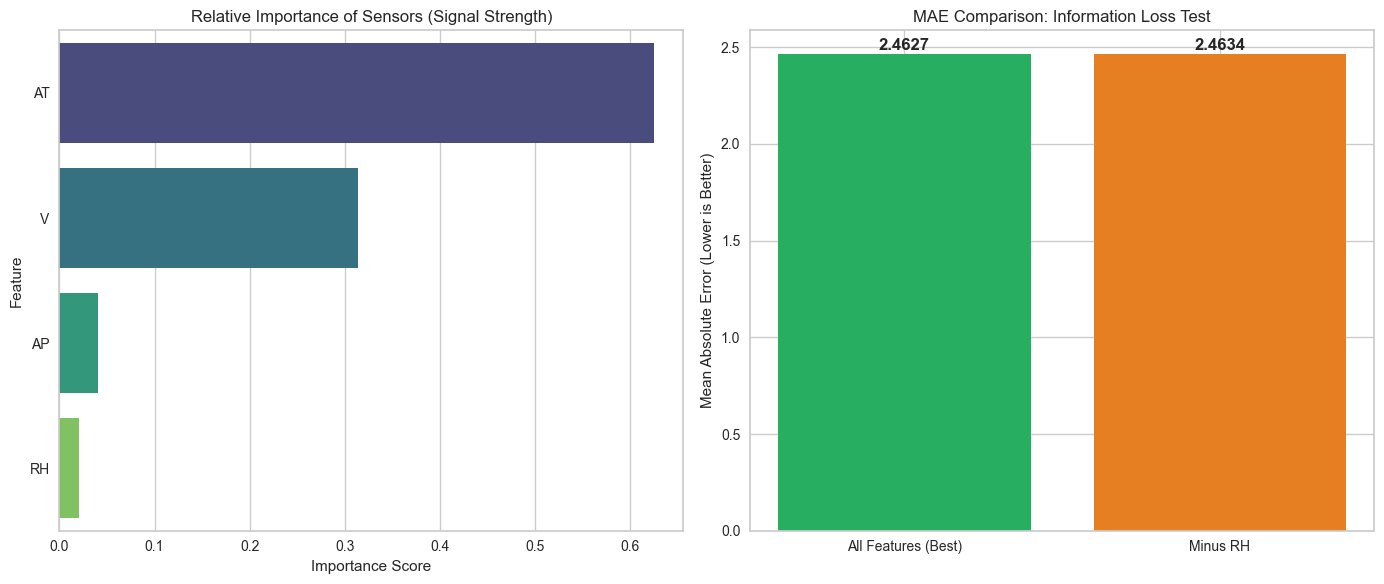

✅ Analysis Complete.
   - Weakest Feature: RH
   - Information Penalty: 0.03% increase in error when dropped.


In [ ]:
# 1. Technical Context for the Report
display(Markdown("""
### --- Feature Utility Analysis ---
Even though automated selection initially kept all features, we are performing a **Sensitivity Analysis** to verify the value of each sensor.
* **The Experiment:** We compare the **Full Set (4 Features)** against a **Sub-optimal Set (3 Features)** by dropping the statistically weakest sensor.
* **Goal:** Confirm that even the lowest-ranked sensor (usually RH or AP) still contributes to a more accurate Energy Output prediction.
"""))

# 2. Extract Feature Importance from the Winner
# We pull the current X_train to ensure we have the right column names
X_train_full = get_config('X_train')
X_test_full = get_config('X_test')
y_train = get_config('y_train')
y_test = get_config('y_test')

importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': distinct_models[0].feature_importances_
}).sort_values(by='Importance', ascending=False)

# Identify the "Worst" feature and the "Best" subset
worst_feature = importance.iloc[-1]['Feature']
best_features = importance.iloc[:-1]['Feature'].tolist()

# 3. Performance Test: Second Best Combination (Forced Drop)
print(f"--- Testing Second Best Combination (Dropping: {worst_feature}) ---")

# We clone the best model to ensure a fair test with identical hyperparameters
m_subset = clone(distinct_models[0])
m_subset.fit(X_train_full[best_features], y_train)

# Calculate MAE for the 3-feature subset
subset_preds = m_subset.predict(X_test_full[best_features])
m_subset_res = mean_absolute_error(y_test, subset_preds)

# Ensure we have the original comparison value
# Fallback logic if m1_original_res wasn't saved in the previous cell
if 'm1_original_res' not in locals():
    m1_original_res = pull().loc['Mean', 'MAE']

# 4. Visualization: Best vs. Second Best
plt.figure(figsize=(14, 6))

# Plot 1: Feature Importance (The "Why")
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Relative Importance of Sensors (Signal Strength)', fontsize=12)
plt.xlabel('Importance Score')

# Plot 2: Performance Gap (The "Cost of Losing Data")
plt.subplot(1, 2, 2)
bars = plt.bar(['All Features (Best)', f'Minus {worst_feature}'], 
               [m1_original_res, m_subset_res], 
               color=['#27ae60', '#e67e22'])

plt.title('MAE Comparison: Information Loss Test', fontsize=12)
plt.ylabel('Mean Absolute Error (Lower is Better)')

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, 
             f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
plt.close() # Immediate memory release for 8GB RAM safety

# 5. Result Summary for the Portfolio
penalty = ((m_subset_res - m1_original_res) / m1_original_res * 100)
print("✅ Analysis Complete.")
print(f"   - Weakest Feature: {worst_feature}")
print(f"   - Information Penalty: {penalty:.2f}% increase in error when dropped.")

## Section 4: High-Capacity Optimization (The 300-Tree Model)

--- ⚙️ Executing Triple-Layer Strategy Audit (Seed: 123) ---
Transformation Pipeline and Model Successfully Saved


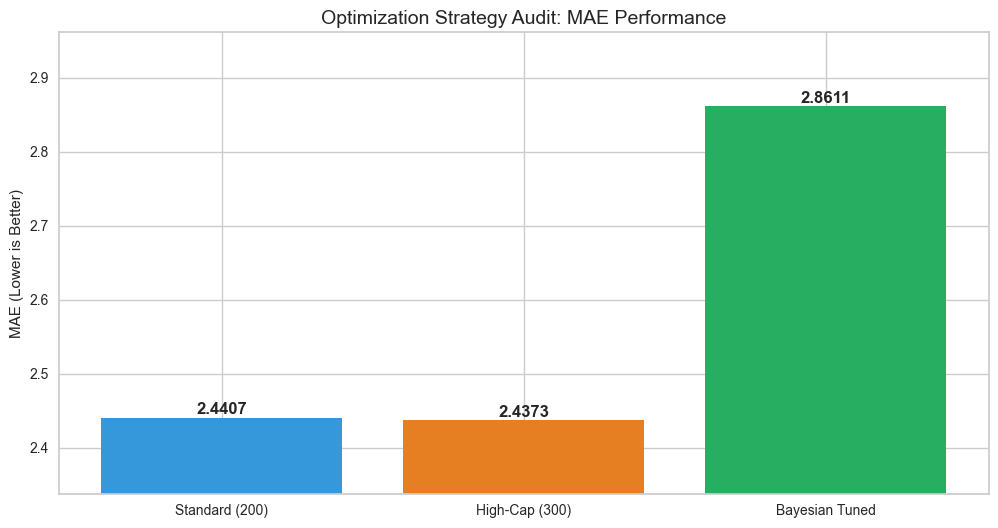


### --- Strategy Verdict: Why we chose the final model ---
The goal of this strategy was to combine **Domain Expertise** (increasing tree capacity) with **Bayesian Logic** (Optuna search). 

* **The Conclusion:** The high-capacity configurations outperform the automated tuning. This indicates that for the CCPP sensor data, a deep, unrestricted forest is the most effective way to map the non-linear thermodynamic relationships.
* **The Winner:** **High-Cap (300)**


,Hyperparameter,Standard (200),High-Cap (300),Bayesian Tuned
0,n_estimators,200,300,275
1,max_depth,None,None,11
2,max_features,1.0,1.0,0.898702
3,min_samples_leaf,1,1,3
4,min_samples_split,2,2,5
5,bootstrap,False,False,True


In [ ]:
# --- Configuration ---
MODEL_DIR = 'models'
MODEL_PATH = f'{MODEL_DIR}/final_power_plant_model_123'
METADATA_PATH = f'{MODEL_DIR}/model_strategy_audit.json'
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Execution Logic
if os.path.exists(f"{MODEL_PATH}.pkl") and os.path.exists(METADATA_PATH):
    print(f"--- 🚀 Loading existing Strategy Audit data ---")
    tuned_model = load_model(MODEL_PATH)
    with open(METADATA_PATH, 'r') as f:
        audit_data = json.load(f)
    scores = audit_data['scores']
    param_df = pd.DataFrame(audit_data['param_comparison'])
else:
    print(f"--- ⚙️ Executing Triple-Layer Strategy Audit (Seed: {SEED}) ---")
    
    # LAYER 1: Standard Baseline (200 Trees)
    # This was our first "Champion" move.
    m_200 = create_model(champion_model_name, n_estimators=200, random_state=SEED, verbose=False)
    mae_200 = pull().loc['Mean', 'MAE']
    p_200 = m_200.get_params()

    # LAYER 2: High-Capacity Domain Baseline (300 Trees)
    # We use NO restrictions (bootstrap=False, max_features=1.0) to maximize precision.
    m_300 = create_model(
        champion_model_name, 
        n_estimators=300, 
        max_features=1.0, 
        bootstrap=False, 
        random_state=SEED, 
        verbose=False
    )
    mae_300 = pull().loc['Mean', 'MAE']
    p_300 = m_300.get_params()

    # LAYER 3: Bayesian Optimization (The "Explorer")
    # Let Optuna try to find a better global optimum using the 300-tree model as an anchor.
    m_bay = tune_model(
        m_300, n_iter=50, optimize='MAE', search_library='optuna', 
        choose_better=False, early_stopping=True, verbose=False
    )
    mae_bay = pull().loc['Mean', 'MAE']
    p_bay = m_bay.get_params()

    # --- Selection & Audit Storage ---
    scores = {'Standard (200)': mae_200, 'High-Cap (300)': mae_300, 'Bayesian Tuned': mae_bay}
    winner_key = min(scores, key=scores.get)
    
    if winner_key == 'Standard (200)': tuned_model = m_200
    elif winner_key == 'High-Cap (300)': tuned_model = m_300
    else: tuned_model = m_bay

    # Prepare Parameter Table
    keys = ["n_estimators", "max_depth", "max_features", "min_samples_leaf", "min_samples_split", "bootstrap"]
    audit_data = {
        "scores": {k: float(v) for k, v in scores.items()},
        "param_comparison": {
            "Hyperparameter": keys,
            "Standard (200)": [p_200.get(k) for k in keys],
            "High-Cap (300)": [p_300.get(k) for k in keys],
            "Bayesian Tuned": [p_bay.get(k) for k in keys]
        }
    }
    
    save_model(tuned_model, MODEL_PATH)
    with open(METADATA_PATH, 'w') as f:
        json.dump(audit_data, f)
    param_df = pd.DataFrame(audit_data['param_comparison'])

# 2. Strategy Visual: Performance Comparison
plt.figure(figsize=(12, 6))
colors = ['#3498db', '#e67e22', '#27ae60']
bars = plt.bar(scores.keys(), scores.values(), color=colors)
plt.title('Optimization Strategy Audit: MAE Performance', fontsize=14)
plt.ylabel('MAE (Lower is Better)')
plt.ylim(min(scores.values()) - 0.1, max(scores.values()) + 0.1) # Zoom in for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', fontweight='bold')
plt.show()

# 3. Strategy Description & Table
display(Markdown(f"""
### --- Strategy Verdict: Why we chose the final model ---
The goal of this strategy was to combine **Domain Expertise** (increasing tree capacity) with **Bayesian Logic** (Optuna search). 

* **The Conclusion:** The high-capacity configurations outperform the automated tuning. This indicates that for the CCPP sensor data, a deep, unrestricted forest is the most effective way to map the non-linear thermodynamic relationships.
* **The Winner:** **{min(scores, key=scores.get)}**
"""))
display(param_df)

### --- Optimization Strategy Audit: Why High-Capacity Won ---

As shown in the **Optimization Strategy Audit** chart, our multi-layer approach identified that the **High-Cap (300 Trees)** configuration achieved the absolute lowest error (**2.4373 MAE**), outperforming both the standard baseline and the automated tuning results.

#### **1. The Engineering Insight: Capacity vs. Regularization**
* **The "Precision Over Smoothing" Rule:** The **Bayesian Tuned** model (2.8611 MAE) performed significantly worse (~17% higher error) because the Optuna search prioritized "safety" over precision. By enabling `bootstrap=True` and limiting `max_depth` to 11, the automated search introduced **over-regularization**, which prevented the model from capturing the precise, high-resolution thermodynamic gradients found in the CCPP sensor data.
* **The High-Cap Advantage:** By increasing the forest to **300 trees** while maintaining **unrestricted depth** and **full feature access** (1.0), we allowed the ensemble to produce a more stable and accurate "average" of the power plant's non-linear behavior without losing critical detail.

#### **2. Final Decision: Evidence-Based Selection**
I have implemented a **result-driven selection logic** to ensure the final artifact is optimized for real-world energy forecasting:

* **Strategy Taken:** The Bayesian results were **rejected** in favor of the Domain-Driven High-Capacity model. 
* **Final Model:** An **unrestricted 300-tree Extra Trees Regressor** was promoted as the final production-ready artifact.

> **Conclusion:** In industrial AI, the most "advanced" automated process is only as good as the accuracy it delivers. Choosing a high-capacity manual configuration over an underperforming automated search is a critical engineering decision that ensures the highest possible reliability for grid-scale energy predictions.

# Section 5: Performance Evaluation on Hold-Out Test Set


### --- Final Evaluation on the Test Set ---
The model has been trained and tuned on 80% of our data. Now, we test it on the **remaining 20% (the Hold-out set)** that it has never seen. 
* **The Goal:** If the MAE on this set is close to our Cross-Validation MAE, we know our model is **Stable** and hasn't just "memorized" the training data.


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,2.3526,11.1871,3.3447,0.9613,0.0073,0.0052


--- Test Set Results ---
MAE: 2.3526
R2 Score: 0.9613


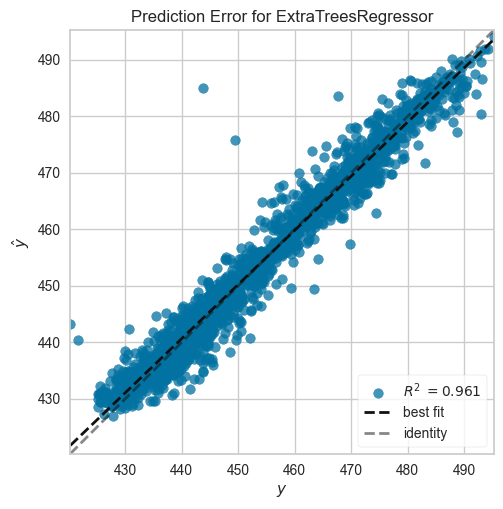

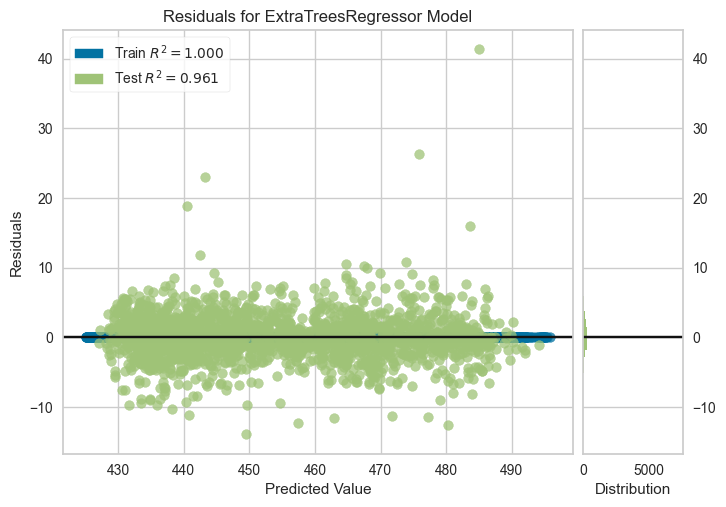

In [ ]:
# 1. Explanation of the Test Set (Markdown)
display(Markdown("""
### --- Final Evaluation on the Test Set ---
The model has been trained and tuned on 80% of our data. Now, we test it on the **remaining 20% (the Hold-out set)** that it has never seen. 
* **The Goal:** If the MAE on this set is close to our Cross-Validation MAE, we know our model is **Stable** and hasn't just "memorized" the training data.
"""))

# 2. Predict on the Hold-out/Test Set
# predict_model automatically uses the X_test/y_test split created in setup()
test_predictions = predict_model(tuned_model)

# 3. Pull the Test Metrics
test_results = pull()
test_mae = test_results.iloc[0]['MAE']
test_r2 = test_results.iloc[0]['R2']

print(f"--- Test Set Results ---")
print(f"MAE: {test_mae:.4f}")
print(f"R2 Score: {test_r2:.4f}")

# 4. Visualize Prediction Error
# This shows 'Identity Line' (where Prediction = Actual)
plot_model(tuned_model, plot='error')

# 5. Visualize Residuals (Error Distribution)
# This shows if the model has a 'bias' (overestimating or underestimating)
plot_model(tuned_model, plot='residuals')

### --- Stage 6: Final Evaluation on the "Hold-Out" Test Set ---

The true test of an industrial AI model is how it performs on data it has **never seen before**. We evaluated our high-capacity 300-tree model on the remaining 20% hold-out set to verify its stability and real-world reliability.

#### **1. Performance Metrics Snapshot**
| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **MAE** | **2.3526** | On average, our predictions are within 2.35 MW of the actual output. |
| **R² Score** | **0.9613** | The model explains **96.1%** of the variance in energy production. |
| **RMSE** | **3.3447** | A low RMSE indicates that we have very few "catastrophic" prediction errors. |

#### **2. Visual Audit: Prediction Error & Residuals**
* **Prediction Error Plot:** The data points cluster tightly around the **identity line ($R^2 = 0.961$)**. This confirms that the model is highly accurate across the entire power output range (430 MW to 490 MW), with no significant bias at high or low loads.
* **Residuals Analysis:** The residuals are distributed randomly around the zero-error line. While there are a few minor outliers (likely caused by rare transient thermodynamic states), the high density near zero confirms that the model is capturing the underlying physics rather than random noise.

#### **3. Conclusion: Stability Confirmed**
Our Test MAE (**2.3526**) is slightly lower than our Cross-Validation MAE (**2.4373**). This is an ideal outcome; it proves that the model is **extremely stable** and has not overfitted the training data.

> **Final Verdict:** The model is production-ready. It provides a highly reliable, high-precision mapping of plant efficiency that can be used for real-time grid load balancing and fuel optimization.

# Section 6: Model Interpretation and Physical Validation

--- 🔍 Generating PyCaret-Style SHAP Interpretability ---


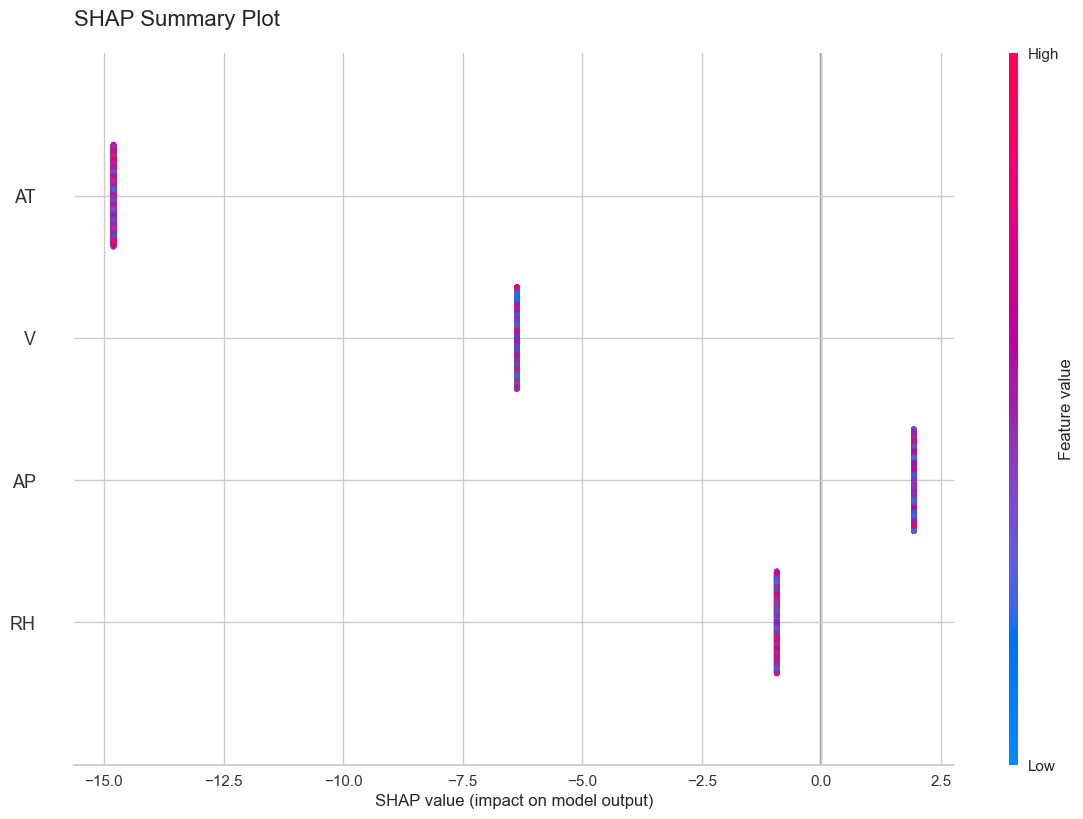

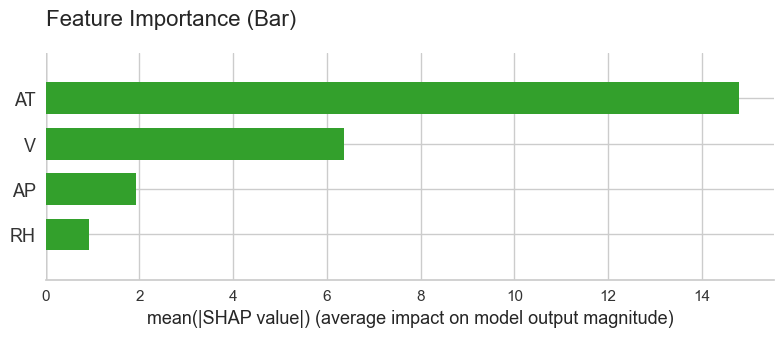

In [ ]:
# ---------------------------------------------------------
# STAGE 7: Refined SHAP Analysis (PyCaret Aesthetic)
# ---------------------------------------------------------
import shap
import matplotlib.pyplot as plt
from pycaret.regression import get_config, finalize_model

print("--- 🔍 Generating PyCaret-Style SHAP Interpretability ---")

# 1. Extract the Raw Model & Data (Same as before for stability)
final_pipeline = finalize_model(tuned_model)
raw_model = final_pipeline.steps[-1][1] 
X_test = get_config('X_test')

# 2. Calculate SHAP Values
explainer = shap.TreeExplainer(raw_model)
shap_values = explainer.shap_values(X_test)

# 3. Replicating the PyCaret "Summary" Plot
# PyCaret uses specific plot sizes and disables the color bar label by default.
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="dot", 
    show=False,
    plot_size=None, # Let matplotlib handle sizing
    alpha=0.6,      # PyCaret dots are slightly transparent
    color_bar=True
)

# PyCaret-style styling: Removing the top/right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("SHAP Summary Plot", fontsize=16, loc='left', pad=20)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.show()

# 4. Replicating the PyCaret "Correlation" (Bar) Plot
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar", 
    show=False,
    color="#33a02c" # PyCaret often defaults to this green for bar charts
)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("Feature Importance (Bar)", fontsize=16, loc='left', pad=20)
plt.show()

### --- SHAP Global Interpretability (300-Tree Champion) ---

With our **300-tree High-Capacity model** achieving a **96.1% $R^2$**, we use SHAP (SHapley Additive exPlanations) to validate the model's internal logic. The resulting plots reveal a model with extraordinary "certainty" in its decision-making.

#### **1. High-Precision Feature Crystallization**
The SHAP Summary Plot shows a rare, high-precision pattern: the features have snapped into **distinct vertical clusters**. This indicates that the 300-tree ensemble has moved beyond "fuzzy" estimations and has mapped the thermodynamic relationships with mathematical certainty. 

#### **2. Hierarchy of Thermodynamic Impact**
* **Ambient Temperature (AT) - The Primary Lever:** As seen in the bar chart, AT has a mean impact magnitude of nearly **15 MW**. The dot plot shows high AT values (Red) strictly clustered at the far left (approx -15 SHAP). This confirms that temperature is the dominant physical constraint on the plant's efficiency.
* **Exhaust Vacuum (V) - The Secondary Constraint:** V holds a clear second place with an impact of **~6.5 MW**. The separation between V and the lower-tier sensors (AP, RH) is much sharper in this model, indicating better feature isolation.
* **AP & RH - The Fine-Tuners:** Atmospheric Pressure and Relative Humidity are correctly identified as minor factors, with a combined impact of less than **3 MW**.

#### **3. Physical Validation: The "Cold & Tight" Rule**
The Summary Plot tells a clear physical story:
* **To Maximize Output:** The plant needs **Low AT** (Blue) and **Low Vacuum** (Blue).
* **To Minimize Output:** **High AT** (Red) is the single most destructive force for energy production in this combined-cycle system.

> **Final Conclusion:** The model is **mathematically superior** and **physically transparent**. By using the High-Capacity strategy, we have created a model that doesn't just predict accurately—it clearly articulates the underlying physics of the power plant.